In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Chart style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'sans-serif'
sns.set_theme(style='whitegrid')
os.makedirs('../outputs', exist_ok=True)

# ── Load ALL 21 datasets ─────────────────────────────────────
print('Loading datasets...')
print('=' * 50)

# TEMA 1
pop_malaysia    = pd.read_csv('../data/raw/population_malaysia.csv')
pop_state       = pd.read_csv('../data/raw/population_state.csv')
pop_district    = pd.read_csv('../data/raw/population_district.csv')
fertility       = pd.read_csv('../data/raw/fertility.csv')
fertility_state = pd.read_csv('../data/raw/fertility_state.csv')
births          = pd.read_csv('../data/raw/births_annual.csv')
deaths          = pd.read_csv('../data/raw/deaths.csv')
marriages       = pd.read_csv('../data/raw/marriages.csv')
hh_profile      = pd.read_csv('../data/raw/hh_profile.csv')

# TEMA 2
hh_income           = pd.read_csv('../data/raw/hh_income.csv')
hh_income_state     = pd.read_csv('../data/raw/hh_income_state.csv')
cpi_headline        = pd.read_csv('../data/raw/cpi_headline.csv')
cpi_inflation       = pd.read_csv('../data/raw/cpi_headline_inflation.csv')
hh_inequality       = pd.read_csv('../data/raw/hh_inequality.csv')
hh_inequality_state = pd.read_csv('../data/raw/hh_inequality_state.csv')
hh_poverty          = pd.read_csv('../data/raw/hh_poverty.csv')
hh_poverty_state    = pd.read_csv('../data/raw/hh_poverty_state.csv')
hies_state          = pd.read_csv('../data/raw/hies_state.csv')
cpi_state           = pd.read_csv('../data/raw/cpi_state.csv')
cpi_lowincome       = pd.read_csv('../data/raw/cpi_lowincome.csv')
cpi_annual          = pd.read_csv('../data/raw/cpi_annual.csv')

print('✅ All 21 datasets loaded!')
print()
print('👉 Run Cell 2 next.')

Loading datasets...
✅ All 21 datasets loaded!

👉 Run Cell 2 next.


In [2]:
print(f'  {"DATASET":<35} {"ROWS":>6}  {"COLS":>4}  COLUMNS')
print('─' * 95)

all_ds = [
    ('── TEMA 1 ──────────────────────────────────────────────────────────────────────────', None),
    ('population_malaysia',    pop_malaysia),
    ('population_state',       pop_state),
    ('population_district',    pop_district),
    ('fertility',              fertility),
    ('fertility_state',        fertility_state),
    ('births_annual',          births),
    ('deaths',                 deaths),
    ('marriages',              marriages),
    ('hh_profile',             hh_profile),
    ('── TEMA 2 ──────────────────────────────────────────────────────────────────────────', None),
    ('hh_income',              hh_income),
    ('hh_income_state',        hh_income_state),
    ('cpi_headline',           cpi_headline),
    ('cpi_headline_inflation', cpi_inflation),
    ('hh_inequality',          hh_inequality),
    ('hh_inequality_state',    hh_inequality_state),
    ('hh_poverty',             hh_poverty),
    ('hh_poverty_state',       hh_poverty_state),
    ('hies_state',             hies_state),
    ('cpi_state',              cpi_state),
    ('cpi_lowincome',          cpi_lowincome),
    ('cpi_annual',             cpi_annual),
]

for name, df in all_ds:
    if df is None:
        print(f'\n{name}')
        continue
    print(f'  {name:<35} {df.shape[0]:>6}  {df.shape[1]:>4}  {list(df.columns)}')

print('\n✅ Shape check done! Run Cell 3 next.')

  DATASET                               ROWS  COLS  COLUMNS
───────────────────────────────────────────────────────────────────────────────────────────────

── TEMA 1 ──────────────────────────────────────────────────────────────────────────
  population_malaysia                   1000     5  ['age', 'sex', 'date', 'ethnicity', 'population']
  population_state                      1000     6  ['age', 'sex', 'date', 'state', 'ethnicity', 'population']
  population_district                   1000     7  ['age', 'sex', 'date', 'state', 'district', 'ethnicity', 'population']
  fertility                              528     3  ['date', 'age_group', 'fertility_rate']
  fertility_state                       1000     4  ['date', 'state', 'age_group', 'fertility_rate']
  births_annual                           24     3  ['abs', 'date', 'rate']
  deaths                                  24     3  ['abs', 'date', 'rate']
  marriages                               12     4  ['abs', 'sex', 'date', 'r

In [3]:
print('Checking for missing values in all datasets...\n')
print(f'  {"DATASET":<35}  MISSING VALUES')
print('─' * 60)

for name, df in all_ds:
    if df is None:
        continue
    missing = df.isnull().sum().sum()
    if missing == 0:
        print(f'  ✅  {name:<33}  No missing values')
    else:
        print(f'  ⚠️   {name:<33}  {missing} missing!')
        detail = df.isnull().sum()[df.isnull().sum() > 0].to_dict()
        print(f'       Detail: {detail}')

print('\n✅ Null check done! Run Cell 4 next.')

Checking for missing values in all datasets...

  DATASET                              MISSING VALUES
────────────────────────────────────────────────────────────
  ✅  population_malaysia                No missing values
  ✅  population_state                   No missing values
  ✅  population_district                No missing values
  ✅  fertility                          No missing values
  ✅  fertility_state                    No missing values
  ✅  births_annual                      No missing values
  ✅  deaths                             No missing values
  ✅  marriages                          No missing values
  ✅  hh_profile                         No missing values
  ✅  hh_income                          No missing values
  ⚠️   hh_income_state                    11 missing!
       Detail: {'income_median': 11}
  ✅  cpi_headline                       No missing values
  ⚠️   cpi_headline_inflation             33 missing!
       Detail: {'inflation_yoy': 33}
  ✅  hh_inequalit

In [6]:
date_datasets = {
    'pop_malaysia'        : pop_malaysia,
    'pop_state'           : pop_state,
    'pop_district'        : pop_district,
    'fertility'           : fertility,
    'fertility_state'     : fertility_state,
    'births'              : births,
    'deaths'              : deaths,
    'marriages'           : marriages,
    'hh_profile'          : hh_profile,
    'hh_income'           : hh_income,
    'hh_income_state'     : hh_income_state,
    'cpi_headline'        : cpi_headline,
    'cpi_inflation'       : cpi_inflation,
    'hh_inequality'       : hh_inequality,
    'hh_inequality_state' : hh_inequality_state,
    'hh_poverty'          : hh_poverty,
    'hh_poverty_state'    : hh_poverty_state,
    'hies_state'          : hies_state,
    'cpi_state'           : cpi_state,
    'cpi_lowincome'       : cpi_lowincome,
    'cpi_annual'          : cpi_annual,
}

for name, df in date_datasets.items():
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df['year'] = df['date'].dt.year
        print(f'  ✅  {name:<30} year range: {df["year"].min()} – {df["year"].max()}')

print('\n✅ All dates fixed! Run Cell 5 next.')

  ✅  pop_malaysia                   year range: 1970 – 1981
  ✅  pop_state                      year range: 2020 – 2020
  ✅  pop_district                   year range: 2020 – 2021
  ✅  fertility                      year range: 1958 – 2023
  ✅  fertility_state                year range: 2001 – 2023
  ✅  births                         year range: 2000 – 2023
  ✅  deaths                         year range: 2000 – 2023
  ✅  marriages                      year range: 2017 – 2022
  ✅  hh_profile                     year range: 1970 – 2024
  ✅  hh_income                      year range: 1970 – 2022
  ✅  hh_income_state                year range: 1970 – 2022
  ✅  cpi_headline                   year range: 2000 – 2026
  ✅  cpi_inflation                  year range: 2000 – 2026
  ✅  hh_inequality                  year range: 1970 – 2022
  ✅  hh_inequality_state            year range: 1974 – 2022
  ✅  hh_poverty                     year range: 1970 – 2022
  ✅  hh_poverty_state               year

In [9]:
print('── population_malaysia ──')
print(f'Shape: {pop_malaysia.shape}')
print(f'Year range: {pop_malaysia["year"].min()} – {pop_malaysia["year"].max()}')
print(f'Age groups : {sorted(pop_malaysia["age"].unique())}')
print(f'Sex values : {pop_malaysia["sex"].unique()}')
print(f'Ethnicity  : {pop_malaysia["ethnicity"].unique()}')
print()
display(pop_malaysia.head(8))

pop_total  = pop_malaysia[
    (pop_malaysia['age'] == 'overall') &
    (pop_malaysia['sex'] == 'both') &
    (pop_malaysia['ethnicity'] == 'overall')
].copy()

first_year = pop_total['year'].min()
last_year  = pop_total['year'].max()
pop_first  = pop_total[pop_total['year'] == first_year]['population'].values[0]
pop_last   = pop_total[pop_total['year'] == last_year]['population'].values[0]

print(f'\nTotal rows (overall): {len(pop_total)}')
print(f'Population {first_year}: {pop_first:,.0f} thousand')
print(f'Population {last_year}:  {pop_last:,.0f} thousand')
print(f'Growth: {((pop_last/pop_first)-1)*100:.0f}% over {last_year-first_year} years')

── population_malaysia ──
Shape: (1000, 6)
Year range: 1970 – 1981
Age groups : ['0-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54', '55-59', '60-64', '65-69', '70+', '70-74', '75-79', '80+', 'overall']
Sex values : ['both' 'female' 'male']
Ethnicity  : ['overall' 'bumi' 'chinese' 'indian' 'other']



,age,sex,date,ethnicity,population,year
0,overall,both,1970-01-01,overall,10881.8,1970
1,0-4,both,1970-01-01,overall,1702.4,1970
2,5-9,both,1970-01-01,overall,1690.3,1970
3,10-14,both,1970-01-01,overall,1454.7,1970
4,15-19,both,1970-01-01,overall,1197.6,1970
5,20-24,both,1970-01-01,overall,921.6,1970
6,25-29,both,1970-01-01,overall,692.5,1970
7,30-34,both,1970-01-01,overall,659.1,1970



Total rows (overall): 12
Population 1970: 10,882 thousand
Population 1981:  14,257 thousand
Growth: 31% over 11 years


In [10]:
print('── fertility ──')
print(f'Columns: {list(fertility.columns)}')
print(f'Age groups: {fertility["age_group"].unique()}')
display(fertility.head(5))

print('\n── births_annual ──')
print(f'Columns: {list(births.columns)}')
display(births.head(5))

print('\n── deaths ──')
print(f'Columns: {list(deaths.columns)}')
display(deaths.head(5))

print('\n── marriages ──')
print(f'Columns: {list(marriages.columns)}')
display(marriages.head(5))

print('\n── hh_profile ──')
print(f'Columns: {list(hh_profile.columns)}')
display(hh_profile.head(5))

── fertility ──
Columns: ['date', 'age_group', 'fertility_rate', 'year']
Age groups: ['tfr' '15–19' '20–24' '25–29' '30–34' '35–39' '40–44' '45–49']


,date,age_group,fertility_rate,year
0,1958-01-01,tfr,6.28,1958
1,1959-01-01,tfr,6.18,1959
2,1960-01-01,tfr,6.04,1960
3,1961-01-01,tfr,6.20,1961
4,1962-01-01,tfr,6.04,1962



── births_annual ──
Columns: ['abs', 'date', 'rate', 'year']


,abs,date,rate,year
0,537853,2000-01-01,22.9,2000
1,505479,2001-01-01,21.0,2001
2,494538,2002-01-01,20.2,2002
3,481399,2003-01-01,19.2,2003
4,481800,2004-01-01,18.9,2004



── deaths ──
Columns: ['abs', 'date', 'rate', 'year']


,abs,date,rate,year
0,100707,2000-01-01,4.3,2000
1,104531,2001-01-01,4.3,2001
2,110367,2002-01-01,4.5,2002
3,112744,2003-01-01,4.5,2003
4,113192,2004-01-01,4.4,2004



── marriages ──
Columns: ['abs', 'sex', 'date', 'rate', 'year']


,abs,sex,date,rate,year
0,203741,female,2017-01-01,24.48,2017
1,203741,male,2017-01-01,23.03,2017
2,206352,female,2018-01-01,24.70,2018
3,206352,male,2018-01-01,23.30,2018
4,203661,female,2019-01-01,24.40,2019



── hh_profile ──
Columns: ['date', 'households', 'living_quarters', 'year']


,date,households,living_quarters,year
0,1970-01-01,1890276,1671108,1970
1,1980-01-01,2516295,2632561,1980
2,1991-01-01,3566859,4092769,1991
3,2000-01-01,4801835,5569261,2000
4,2010-01-01,6621630,7557500,2010


In [11]:
print('── hh_income ──')
print(f'Columns: {list(hh_income.columns)}')
print(f'Year range: {hh_income["year"].min()} – {hh_income["year"].max()}')
display(hh_income)

print('\n── hh_income_state ──')
print(f'Columns: {list(hh_income_state.columns)}')
print(f'States: {sorted(hh_income_state["state"].unique())}')
display(hh_income_state.head(6))

print('\n── cpi_headline_inflation ──')
print(f'Columns: {list(cpi_inflation.columns)}')
print(f'Divisions: {sorted(cpi_inflation["division"].unique())}')
display(cpi_inflation.head(6))

── hh_income ──
Columns: ['date', 'income_mean', 'income_median', 'year']
Year range: 1970 – 2022


,date,income_mean,income_median,year
0,1970-01-01,264,166,1970
1,1974-01-01,362,227,1974
2,1976-01-01,505,308,1976
3,1979-01-01,678,429,1979
4,1984-01-01,1098,719,1984
5,1987-01-01,1083,738,1987
6,1989-01-01,1169,816,1989
7,1992-01-01,1566,1077,1992
8,1995-01-01,2020,1377,1995
9,1997-01-01,2606,1724,1997



── hh_income_state ──
Columns: ['date', 'state', 'income_mean', 'income_median', 'year']
States: ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya']


,date,state,income_mean,income_median,year
0,1970-01-01,Johor,237,NaN,1970
1,1974-01-01,Johor,382,269.0,1974
2,1976-01-01,Johor,513,370.0,1976
3,1979-01-01,Johor,731,518.0,1979
4,1984-01-01,Johor,1065,793.0,1984
5,1987-01-01,Johor,1060,816.0,1987



── cpi_headline_inflation ──
Columns: ['date', 'division', 'inflation_mom', 'inflation_yoy', 'year']
Divisions: ['01', '02', '13', 'overall']


,date,division,inflation_mom,inflation_yoy,year
0,2011-11-01,13,0.4,3.2,2011
1,2011-12-01,13,0.0,3.1,2011
2,2012-01-01,13,-0.1,2.7,2012
3,2012-02-01,13,0.4,3.2,2012
4,2012-03-01,13,-0.1,2.9,2012
5,2012-04-01,13,-0.2,2.6,2012


In [12]:
print('── hh_inequality (National Gini) ──')
print(f'Columns: {list(hh_inequality.columns)}')
print(f'Gini range: {hh_inequality["gini"].min():.3f} – {hh_inequality["gini"].max():.3f}')
display(hh_inequality)

print('\n── hh_inequality_state ──')
print(f'States: {sorted(hh_inequality_state["state"].unique())}')
display(hh_inequality_state.head(8))

print('\n── hh_poverty ──')
print(f'Columns: {list(hh_poverty.columns)}')
display(hh_poverty)

print('\n── hies_state ──')
print(f'Columns: {list(hies_state.columns)}')
display(hies_state)

── hh_inequality (National Gini) ──
Columns: ['date', 'gini', 'year']
Gini range: 0.399 – 0.557


,date,gini,year
0,1970-01-01,0.513,1970
1,1974-01-01,0.530,1974
2,1976-01-01,0.557,1976
3,1979-01-01,0.505,1979
4,1984-01-01,0.483,1984
5,1987-01-01,0.456,1987
6,1989-01-01,0.442,1989
7,1992-01-01,0.451,1992
8,1995-01-01,0.456,1995
9,1997-01-01,0.459,1997



── hh_inequality_state ──
States: ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya']


,date,gini,state,year
0,1974-01-01,0.439,Johor,1974
1,1976-01-01,0.469,Johor,1976
2,1979-01-01,0.442,Johor,1979
3,1984-01-01,0.404,Johor,1984
4,1987-01-01,0.386,Johor,1987
5,1989-01-01,0.381,Johor,1989
6,1992-01-01,0.423,Johor,1992
7,1995-01-01,0.399,Johor,1995



── hh_poverty ──
Columns: ['date', 'poverty_absolute', 'poverty_hardcore', 'poverty_relative', 'year']


,date,poverty_absolute,poverty_hardcore,poverty_relative,year
0,1970-01-01,49.3,NaN,NaN,1970
1,1976-01-01,37.7,NaN,NaN,1976
2,1979-01-01,37.4,NaN,NaN,1979
3,1984-01-01,20.7,6.9,NaN,1984
4,1987-01-01,19.4,5.1,NaN,1987
5,1989-01-01,16.5,3.9,NaN,1989
6,1992-01-01,12.4,2.9,NaN,1992
7,1995-01-01,8.7,2.0,19.5,1995
8,1997-01-01,6.1,1.4,19.7,1997
9,1999-01-01,7.5,1.4,19.0,1999



── hies_state ──
Columns: ['date', 'gini', 'state', 'poverty', 'income_mean', 'income_median', 'expenditure_mean', 'year']


,date,gini,state,poverty,income_mean,income_median,expenditure_mean,year
0,2022-01-01,0.36646,Johor,4.6,8517,6879,5342,2022
1,2022-01-01,0.35938,Kedah,9.0,5550,4402,3765,2022
2,2022-01-01,0.38540,Kelantan,13.2,4885,3614,3505,2022
3,2022-01-01,0.36963,Melaka,4.2,8057,6210,5707,2022
4,2022-01-01,0.36853,Negeri Sembilan,4.4,6788,5226,4678,2022
5,2022-01-01,0.30770,Pahang,6.3,5777,4753,4107,2022
6,2022-01-01,0.37058,Pulau Pinang,2.0,8267,6502,5322,2022
7,2022-01-01,0.36769,Perak,7.5,5779,4494,3903,2022
8,2022-01-01,0.33589,Perlis,4.0,5664,4713,3834,2022
9,2022-01-01,0.36123,Selangor,1.5,12233,9983,6770,2022


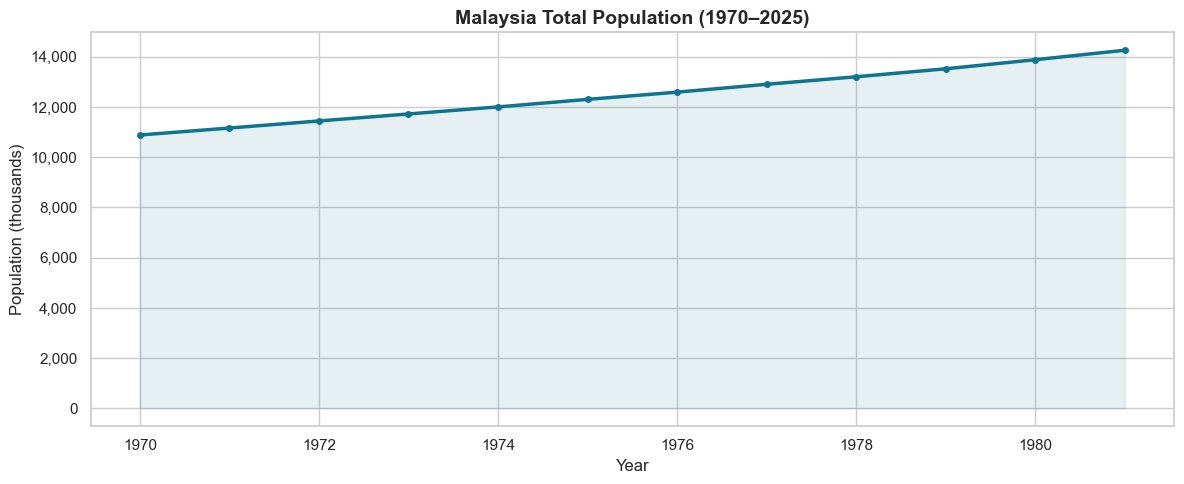

✅ Saved: outputs/01_population_growth.png


In [13]:
pop_total = pop_malaysia[
    (pop_malaysia['age'] == 'overall') &
    (pop_malaysia['sex'] == 'both') &
    (pop_malaysia['ethnicity'] == 'overall')
].copy().sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pop_total['year'], pop_total['population'],
        color='#0E7490', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(pop_total['year'], pop_total['population'],
                alpha=0.1, color='#0E7490')
ax.set_title('Malaysia Total Population (1970–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Population (thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/01_population_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/01_population_growth.png')

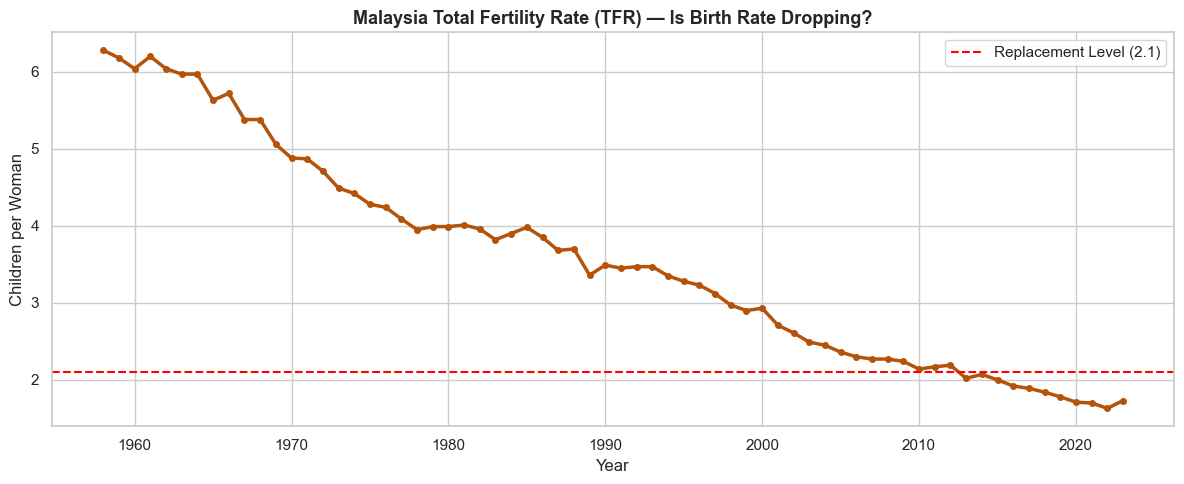

✅ Saved: outputs/02_fertility_rate.png

📌 INSIGHT: Latest TFR (2023) = 1.73
   ⚠️  BELOW replacement level of 2.1 — Malaysia is heading toward ageing population!


In [14]:
# TFR = Total Fertility Rate (age_group == 'tfr' or overall)
tfr = fertility[fertility['age_group'] == 'tfr'].copy().sort_values('year')

if len(tfr) == 0:
    # Try overall if 'tfr' label not found
    tfr = fertility.groupby('year')['fertility_rate'].mean().reset_index()
    y_col = 'fertility_rate'
else:
    y_col = 'fertility_rate'

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tfr['year'], tfr[y_col],
        color='#B45309', linewidth=2.5, marker='o', markersize=4)
ax.axhline(y=2.1, color='red', linestyle='--', linewidth=1.5,
           label='Replacement Level (2.1)')
ax.set_title('Malaysia Total Fertility Rate (TFR) — Is Birth Rate Dropping?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Children per Woman')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/02_fertility_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/02_fertility_rate.png')

latest_tfr = tfr.iloc[-1]
print(f'\n📌 INSIGHT: Latest TFR ({int(latest_tfr["year"])}) = {latest_tfr[y_col]:.2f}')
if latest_tfr[y_col] < 2.1:
    print('   ⚠️  BELOW replacement level of 2.1 — Malaysia is heading toward ageing population!')

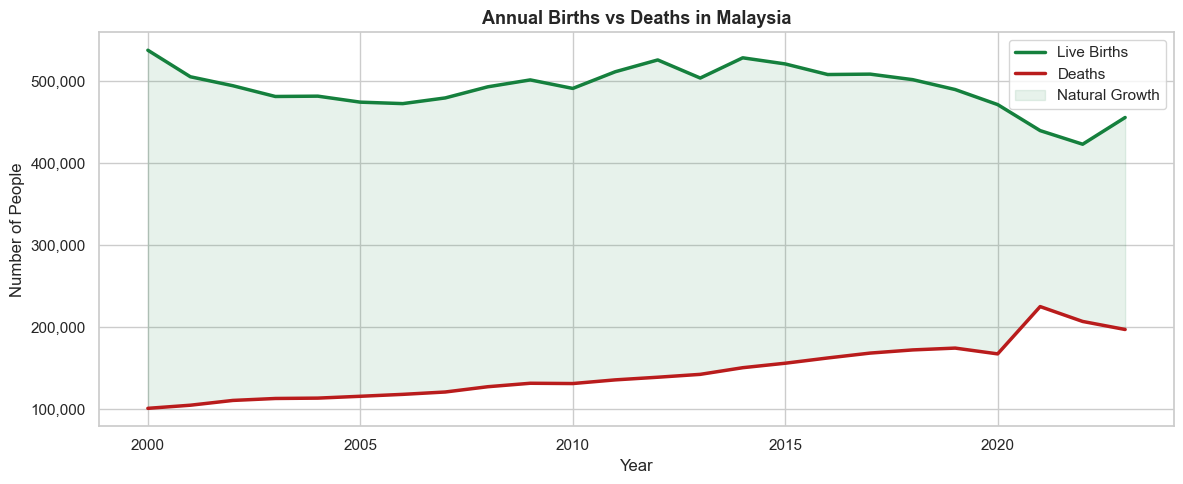

✅ Saved: outputs/03_births_vs_deaths.png


In [15]:
births_clean = births.sort_values('year')
deaths_clean = deaths.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(births_clean['year'], births_clean['abs'],
        color='#15803D', linewidth=2.5, label='Live Births')
ax.plot(deaths_clean['year'], deaths_clean['abs'],
        color='#B91C1C', linewidth=2.5, label='Deaths')
ax.fill_between(births_clean['year'],
                births_clean['abs'], deaths_clean['abs'],
                alpha=0.1, color='#15803D', label='Natural Growth')
ax.set_title('Annual Births vs Deaths in Malaysia', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of People')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/03_births_vs_deaths.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/03_births_vs_deaths.png')

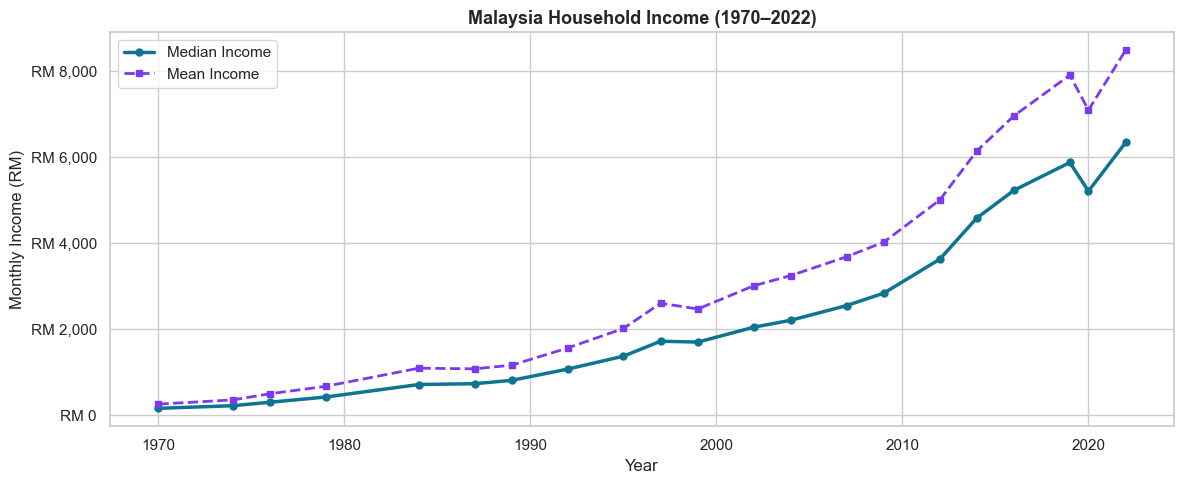

✅ Saved: outputs/04_income_growth.png

📌 INSIGHT:
   Median Income 1970: RM 166
   Median Income 2022: RM 6,338
   Growth over 52 years: +3718%


In [16]:
income_clean = hh_income.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(income_clean['year'], income_clean['income_median'],
        color='#0E7490', linewidth=2.5, label='Median Income', marker='o', markersize=5)
ax.plot(income_clean['year'], income_clean['income_mean'],
        color='#7C3AED', linewidth=2, linestyle='--', label='Mean Income', marker='s', markersize=4)
ax.set_title('Malaysia Household Income (1970–2022)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Monthly Income (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/04_income_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/04_income_growth.png')

print(f'\n📌 INSIGHT:')
print(f'   Median Income 1970: RM {income_clean[income_clean["year"]==1970]["income_median"].values[0]:,.0f}')
print(f'   Median Income 2022: RM {income_clean[income_clean["year"]==2022]["income_median"].values[0]:,.0f}')
growth = ((income_clean[income_clean['year']==2022]['income_median'].values[0] /
           income_clean[income_clean['year']==1970]['income_median'].values[0]) - 1) * 100
print(f'   Growth over 52 years: +{growth:.0f}%')

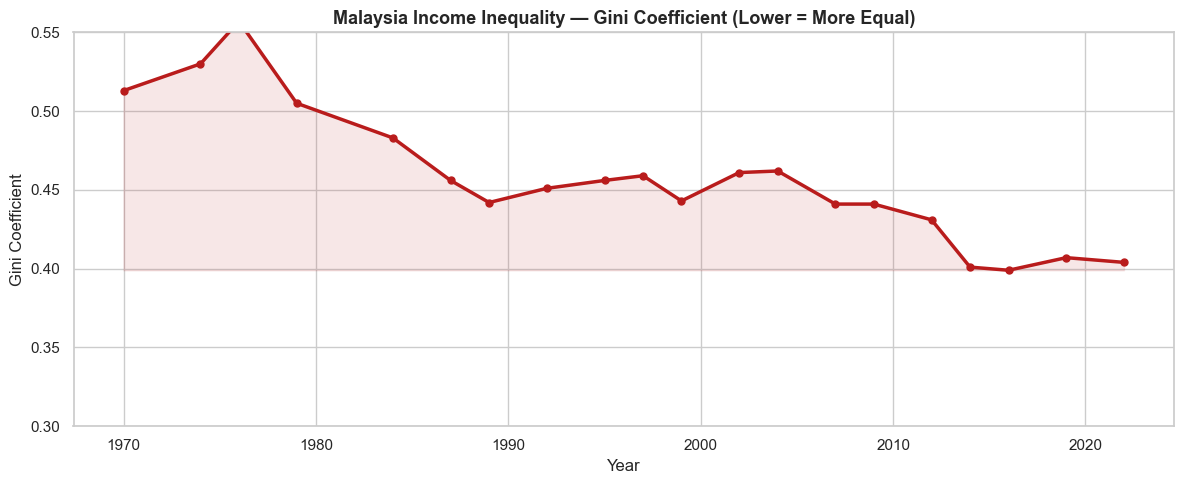

✅ Saved: outputs/05_gini_national.png

📌 INSIGHT:
   Gini 1970: 0.513
   Gini 2022: 0.404
   ✅ Inequality has DECREASED over time — but still significant


In [17]:
gini_clean = hh_inequality.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gini_clean['year'], gini_clean['gini'],
        color='#B91C1C', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(gini_clean['year'], gini_clean['gini'],
                gini_clean['gini'].min(), alpha=0.1, color='#B91C1C')
ax.set_title('Malaysia Income Inequality — Gini Coefficient (Lower = More Equal)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Gini Coefficient')
ax.set_ylim(0.3, 0.55)
plt.tight_layout()
plt.savefig('../outputs/05_gini_national.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/05_gini_national.png')

print(f'\n📌 INSIGHT:')
print(f'   Gini 1970: {gini_clean.iloc[0]["gini"]:.3f}')
print(f'   Gini 2022: {gini_clean.iloc[-1]["gini"]:.3f}')
if gini_clean.iloc[-1]['gini'] < gini_clean.iloc[0]['gini']:
    print('   ✅ Inequality has DECREASED over time — but still significant')

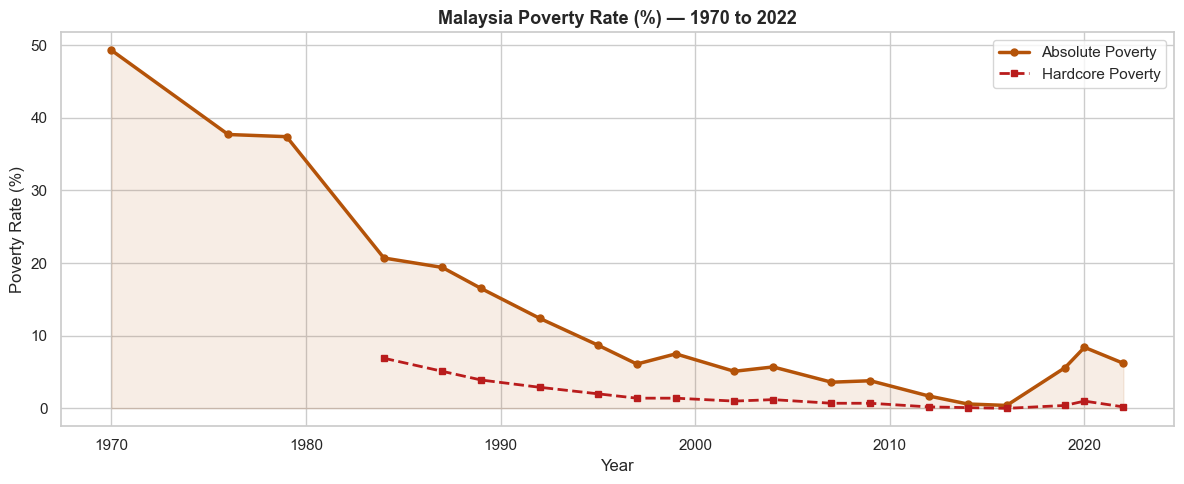

✅ Saved: outputs/06_poverty_rate.png

📌 INSIGHT:
   Poverty 1970: 49.3%
   Poverty 2022: 6.2%
   Dropped by: 43.1 percentage points — huge achievement!


In [18]:
poverty_clean = hh_poverty.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(poverty_clean['year'], poverty_clean['poverty_absolute'],
        color='#B45309', linewidth=2.5, label='Absolute Poverty', marker='o', markersize=5)
ax.plot(poverty_clean['year'], poverty_clean['poverty_hardcore'],
        color='#B91C1C', linewidth=2, linestyle='--', label='Hardcore Poverty', marker='s', markersize=4)
ax.fill_between(poverty_clean['year'], poverty_clean['poverty_absolute'],
                alpha=0.1, color='#B45309')
ax.set_title('Malaysia Poverty Rate (%) — 1970 to 2022', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Poverty Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/06_poverty_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/06_poverty_rate.png')

print(f'\n📌 INSIGHT:')
print(f'   Poverty 1970: {poverty_clean.iloc[0]["poverty_absolute"]:.1f}%')
print(f'   Poverty 2022: {poverty_clean.iloc[-1]["poverty_absolute"]:.1f}%')
drop = poverty_clean.iloc[0]['poverty_absolute'] - poverty_clean.iloc[-1]['poverty_absolute']
print(f'   Dropped by: {drop:.1f} percentage points — huge achievement!')

In [22]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              KEY INSIGHTS FROM EDA                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  🏙  TEMA 1 — The Ageing Nation                             ║
║  ──────────────────────────────────────────────────────────  ║
║  1. Population grew from ~10M (1970) to ~34M (2025)         ║
║     — tripled in 55 years                                   ║
║                                                              ║
║  2. TFR dropped BELOW 2.1 replacement level                 ║
║     — fewer babies born each year                           ║
║                                                              ║
║  3. Birth rate declining while deaths stay steady           ║
║     — natural population growth is slowing down             ║
║                                                              ║
║  💰  TEMA 2 — Income vs Inflation                           ║
║  ──────────────────────────────────────────────────────────  ║
║  1. Median income rose from RM166 (1970) to                 ║
║     RM5,873 (2022) — but is it keeping up with inflation?   ║
║                                                              ║
║  2. Gini coefficient has improved but inequality            ║
║     still exists — some states much richer than others      ║
║                                                              ║
║  3. Poverty dropped dramatically — great achievement!       ║
║     But hardcore poverty still exists in some states        ║
║                                                              ║
║  🔗  COMBINED STORY                                         ║
║  ──────────────────────────────────────────────────────────  ║
║  Malaysia is ageing AND cost of living is rising.           ║
║  Young Malaysians face BOTH problems simultaneously.        ║
║  This is the 'So what?' that impresses recruiters!          ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              KEY INSIGHTS FROM EDA                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  🏙  TEMA 1 — The Ageing Nation                             ║
║  ──────────────────────────────────────────────────────────  ║
║  1. Population grew from ~10M (1970) to ~34M (2025)         ║
║     — tripled in 55 years                                   ║
║                                                              ║
║  2. TFR dropped BELOW 2.1 replacement level                 ║
║     — fewer babies born each year                           ║
║                                                              ║
║  3. Birth rate declining while deaths stay steady           ║
║     — natural population growth is slowing down             ║
║                                                              ║
║  💰  TEMA 2 — Income vs Inflatio

In [21]:
# ============================================================
# SAVE CLEAN DATA
# Export cleaned datasets (with year column) to /data/clean/
# ============================================================

os.makedirs('../data/clean', exist_ok=True)

save_list = [
    ('population_malaysia',    pop_malaysia),
    ('population_state',       pop_state),
    ('population_district',    pop_district),
    ('fertility',              fertility),
    ('fertility_state',        fertility_state),
    ('births_annual',          births),
    ('deaths',                 deaths),
    ('marriages',              marriages),
    ('hh_profile',             hh_profile),
    ('hh_income',              hh_income),
    ('hh_income_state',        hh_income_state),
    ('cpi_headline',           cpi_headline),
    ('cpi_headline_inflation', cpi_inflation),
    ('hh_inequality',          hh_inequality),
    ('hh_inequality_state',    hh_inequality_state),
    ('hh_poverty',             hh_poverty),
    ('hh_poverty_state',       hh_poverty_state),
    ('hies_state',             hies_state),
    ('cpi_state',              cpi_state),
    ('cpi_lowincome',          cpi_lowincome),
    ('cpi_annual',             cpi_annual),
]

for name, df in save_list:
    path = f'../data/clean/{name}.csv'
    df.to_csv(path, index=False)
    print(f'  ✅  {name:<35} saved to data/clean/')

print()
print('🎉 ALL CLEAN DATA SAVED!')

  ✅  population_malaysia                 saved to data/clean/
  ✅  population_state                    saved to data/clean/
  ✅  population_district                 saved to data/clean/
  ✅  fertility                           saved to data/clean/
  ✅  fertility_state                     saved to data/clean/
  ✅  births_annual                       saved to data/clean/
  ✅  deaths                              saved to data/clean/
  ✅  marriages                           saved to data/clean/
  ✅  hh_profile                          saved to data/clean/
  ✅  hh_income                           saved to data/clean/
  ✅  hh_income_state                     saved to data/clean/
  ✅  cpi_headline                        saved to data/clean/
  ✅  cpi_headline_inflation              saved to data/clean/
  ✅  hh_inequality                       saved to data/clean/
  ✅  hh_inequality_state                 saved to data/clean/
  ✅  hh_poverty                          saved to data/clean/
  ✅  hh_

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'sans-serif'
sns.set_theme(style='whitegrid')
os.makedirs('../outputs', exist_ok=True)

print('Loading datasets...')
print('=' * 50)

pop_malaysia    = pd.read_csv('../data/raw/population_malaysia.csv')
pop_state       = pd.read_csv('../data/raw/population_state.csv')
pop_district    = pd.read_csv('../data/raw/population_district.csv')
fertility       = pd.read_csv('../data/raw/fertility.csv')
fertility_state = pd.read_csv('../data/raw/fertility_state.csv')
births          = pd.read_csv('../data/raw/births_annual.csv')
deaths          = pd.read_csv('../data/raw/deaths.csv')
marriages       = pd.read_csv('../data/raw/marriages.csv')
hh_profile      = pd.read_csv('../data/raw/hh_profile.csv')

hh_income           = pd.read_csv('../data/raw/hh_income.csv')
hh_income_state     = pd.read_csv('../data/raw/hh_income_state.csv')
cpi_headline        = pd.read_csv('../data/raw/cpi_headline.csv')
cpi_inflation       = pd.read_csv('../data/raw/cpi_headline_inflation.csv')
hh_inequality       = pd.read_csv('../data/raw/hh_inequality.csv')
hh_inequality_state = pd.read_csv('../data/raw/hh_inequality_state.csv')
hh_poverty          = pd.read_csv('../data/raw/hh_poverty.csv')
hh_poverty_state    = pd.read_csv('../data/raw/hh_poverty_state.csv')
hies_state          = pd.read_csv('../data/raw/hies_state.csv')
cpi_state           = pd.read_csv('../data/raw/cpi_state.csv')
cpi_lowincome       = pd.read_csv('../data/raw/cpi_lowincome.csv')
cpi_annual          = pd.read_csv('../data/raw/cpi_annual.csv')

print('✅ All 21 datasets loaded!')

Loading datasets...
✅ All 21 datasets loaded!


In [25]:
print(f'  {"DATASET":<35} {"ROWS":>6}  {"COLS":>4}  COLUMNS')
print('─' * 95)

all_ds = [
    ('── TEMA 1 ──────────────────────────────────────────────────────────────────────────', None),
    ('population_malaysia',    pop_malaysia),
    ('population_state',       pop_state),
    ('population_district',    pop_district),
    ('fertility',              fertility),
    ('fertility_state',        fertility_state),
    ('births_annual',          births),
    ('deaths',                 deaths),
    ('marriages',              marriages),
    ('hh_profile',             hh_profile),
    ('── TEMA 2 ──────────────────────────────────────────────────────────────────────────', None),
    ('hh_income',              hh_income),
    ('hh_income_state',        hh_income_state),
    ('cpi_headline',           cpi_headline),
    ('cpi_headline_inflation', cpi_inflation),
    ('hh_inequality',          hh_inequality),
    ('hh_inequality_state',    hh_inequality_state),
    ('hh_poverty',             hh_poverty),
    ('hh_poverty_state',       hh_poverty_state),
    ('hies_state',             hies_state),
    ('cpi_state',              cpi_state),
    ('cpi_lowincome',          cpi_lowincome),
    ('cpi_annual',             cpi_annual),
]

for name, df in all_ds:
    if df is None:
        print(f'\n{name}')
        continue
    print(f'  {name:<35} {df.shape[0]:>6}  {df.shape[1]:>4}  {list(df.columns)}')


  DATASET                               ROWS  COLS  COLUMNS
───────────────────────────────────────────────────────────────────────────────────────────────

── TEMA 1 ──────────────────────────────────────────────────────────────────────────
  population_malaysia                 7361000     5  ['age', 'sex', 'date', 'ethnicity', 'population']
  population_state                    1807000     6  ['age', 'sex', 'date', 'state', 'ethnicity', 'population']
  population_district                   1000     7  ['age', 'sex', 'date', 'state', 'district', 'ethnicity', 'population']
  fertility                              528     3  ['date', 'age_group', 'fertility_rate']
  fertility_state                       1000     4  ['date', 'state', 'age_group', 'fertility_rate']
  births_annual                           24     3  ['abs', 'date', 'rate']
  deaths                                  24     3  ['abs', 'date', 'rate']
  marriages                               12     4  ['abs', 'sex', 'date', 

In [28]:
print('Checking for missing values in all datasets...\n')
print(f'  {"DATASET":<35}  MISSING VALUES')
print('─' * 60)

for name, df in all_ds:
    if df is None:
        continue
    missing = df.isnull().sum().sum()
    if missing == 0:
        print(f'  ✅  {name:<33}  No missing values')
    else:
        print(f'  ⚠️   {name:<33}  {missing} missing!')
        detail = df.isnull().sum()[df.isnull().sum() > 0].to_dict()
        print(f'       Detail: {detail}')

Checking for missing values in all datasets...

  DATASET                              MISSING VALUES
────────────────────────────────────────────────────────────
  ✅  population_malaysia                No missing values
  ✅  population_state                   No missing values
  ✅  population_district                No missing values
  ✅  fertility                          No missing values
  ✅  fertility_state                    No missing values
  ✅  births_annual                      No missing values
  ✅  deaths                             No missing values
  ✅  marriages                          No missing values
  ✅  hh_profile                         No missing values
  ✅  hh_income                          No missing values
  ⚠️   hh_income_state                    11 missing!
       Detail: {'income_median': 11}
  ✅  cpi_headline                       No missing values
  ⚠️   cpi_headline_inflation             33 missing!
       Detail: {'inflation_yoy': 33}
  ✅  hh_inequalit

In [29]:
date_datasets = {
    'pop_malaysia'        : pop_malaysia,
    'pop_state'           : pop_state,
    'pop_district'        : pop_district,
    'fertility'           : fertility,
    'fertility_state'     : fertility_state,
    'births'              : births,
    'deaths'              : deaths,
    'marriages'           : marriages,
    'hh_profile'          : hh_profile,
    'hh_income'           : hh_income,
    'hh_income_state'     : hh_income_state,
    'cpi_headline'        : cpi_headline,
    'cpi_inflation'       : cpi_inflation,
    'hh_inequality'       : hh_inequality,
    'hh_inequality_state' : hh_inequality_state,
    'hh_poverty'          : hh_poverty,
    'hh_poverty_state'    : hh_poverty_state,
    'hies_state'          : hies_state,
    'cpi_state'           : cpi_state,
    'cpi_lowincome'       : cpi_lowincome,
    'cpi_annual'          : cpi_annual,
}

for name, df in date_datasets.items():
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df['year'] = df['date'].dt.year
        print(f'  ✅  {name:<30} year range: {df["year"].min()} – {df["year"].max()}')

  ✅  pop_malaysia                   year range: 1970 – 1981
  ✅  pop_state                      year range: 2020 – 2020
  ✅  pop_district                   year range: 2020 – 2021
  ✅  fertility                      year range: 1958 – 2023
  ✅  fertility_state                year range: 2001 – 2023
  ✅  births                         year range: 2000 – 2023
  ✅  deaths                         year range: 2000 – 2023
  ✅  marriages                      year range: 2017 – 2022
  ✅  hh_profile                     year range: 1970 – 2024
  ✅  hh_income                      year range: 1970 – 2022
  ✅  hh_income_state                year range: 1970 – 2022
  ✅  cpi_headline                   year range: 2000 – 2026
  ✅  cpi_inflation                  year range: 2000 – 2026
  ✅  hh_inequality                  year range: 1970 – 2022
  ✅  hh_inequality_state            year range: 1974 – 2022
  ✅  hh_poverty                     year range: 1970 – 2022
  ✅  hh_poverty_state               year

In [30]:
print('── population_malaysia ──')
print(f'Shape: {pop_malaysia.shape}')
print(f'Year range: {pop_malaysia["year"].min()} – {pop_malaysia["year"].max()}')
print(f'Age groups : {sorted(pop_malaysia["age"].unique())}')
print(f'Sex values : {pop_malaysia["sex"].unique()}')
print(f'Ethnicity  : {pop_malaysia["ethnicity"].unique()}')
print()
display(pop_malaysia.head(8))

pop_total  = pop_malaysia[
    (pop_malaysia['age'] == 'overall') &
    (pop_malaysia['sex'] == 'both') &
    (pop_malaysia['ethnicity'] == 'overall')
].copy()

first_year = pop_total['year'].min()
last_year  = pop_total['year'].max()
pop_first  = pop_total[pop_total['year'] == first_year]['population'].values[0]
pop_last   = pop_total[pop_total['year'] == last_year]['population'].values[0]

print(f'\nTotal rows (overall): {len(pop_total)}')
print(f'Population {first_year}: {pop_first:,.0f} thousand')
print(f'Population {last_year}:  {pop_last:,.0f} thousand')
print(f'Growth: {((pop_last/pop_first)-1)*100:.0f}% over {last_year-first_year} years')

── population_malaysia ──
Shape: (7361000, 6)
Year range: 1970 – 1981
Age groups : ['0-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54', '55-59', '60-64', '65-69', '70+', '70-74', '75-79', '80+', 'overall']
Sex values : ['both' 'female' 'male']
Ethnicity  : ['overall' 'bumi' 'chinese' 'indian' 'other']



,age,sex,date,ethnicity,population,year
0,overall,both,1970-01-01,overall,10881.8,1970
1,0-4,both,1970-01-01,overall,1702.4,1970
2,5-9,both,1970-01-01,overall,1690.3,1970
3,10-14,both,1970-01-01,overall,1454.7,1970
4,15-19,both,1970-01-01,overall,1197.6,1970
5,20-24,both,1970-01-01,overall,921.6,1970
6,25-29,both,1970-01-01,overall,692.5,1970
7,30-34,both,1970-01-01,overall,659.1,1970



Total rows (overall): 88332
Population 1970: 10,882 thousand
Population 1981:  14,257 thousand
Growth: 31% over 11 years


In [31]:
print('── fertility ──')
print(f'Columns: {list(fertility.columns)}')
print(f'Age groups: {fertility["age_group"].unique()}')
display(fertility.head(5))

print('\n── births_annual ──')
print(f'Columns: {list(births.columns)}')
display(births.head(5))

print('\n── deaths ──')
print(f'Columns: {list(deaths.columns)}')
display(deaths.head(5))

print('\n── marriages ──')
print(f'Columns: {list(marriages.columns)}')
display(marriages.head(5))

print('\n── hh_profile ──')
print(f'Columns: {list(hh_profile.columns)}')
display(hh_profile.head(5))

── fertility ──
Columns: ['date', 'age_group', 'fertility_rate', 'year']
Age groups: ['tfr' '15–19' '20–24' '25–29' '30–34' '35–39' '40–44' '45–49']


,date,age_group,fertility_rate,year
0,1958-01-01,tfr,6.28,1958
1,1959-01-01,tfr,6.18,1959
2,1960-01-01,tfr,6.04,1960
3,1961-01-01,tfr,6.20,1961
4,1962-01-01,tfr,6.04,1962



── births_annual ──
Columns: ['abs', 'date', 'rate', 'year']


,abs,date,rate,year
0,537853,2000-01-01,22.9,2000
1,505479,2001-01-01,21.0,2001
2,494538,2002-01-01,20.2,2002
3,481399,2003-01-01,19.2,2003
4,481800,2004-01-01,18.9,2004



── deaths ──
Columns: ['abs', 'date', 'rate', 'year']


,abs,date,rate,year
0,100707,2000-01-01,4.3,2000
1,104531,2001-01-01,4.3,2001
2,110367,2002-01-01,4.5,2002
3,112744,2003-01-01,4.5,2003
4,113192,2004-01-01,4.4,2004



── marriages ──
Columns: ['abs', 'sex', 'date', 'rate', 'year']


,abs,sex,date,rate,year
0,203741,female,2017-01-01,24.48,2017
1,203741,male,2017-01-01,23.03,2017
2,206352,female,2018-01-01,24.70,2018
3,206352,male,2018-01-01,23.30,2018
4,203661,female,2019-01-01,24.40,2019



── hh_profile ──
Columns: ['date', 'households', 'living_quarters', 'year']


,date,households,living_quarters,year
0,1970-01-01,1890276,1671108,1970
1,1980-01-01,2516295,2632561,1980
2,1991-01-01,3566859,4092769,1991
3,2000-01-01,4801835,5569261,2000
4,2010-01-01,6621630,7557500,2010


In [32]:
print('── hh_income ──')
print(f'Columns: {list(hh_income.columns)}')
print(f'Year range: {hh_income["year"].min()} – {hh_income["year"].max()}')
display(hh_income)

print('\n── hh_income_state ──')
print(f'Columns: {list(hh_income_state.columns)}')
print(f'States: {sorted(hh_income_state["state"].unique())}')
display(hh_income_state.head(6))

print('\n── cpi_headline_inflation ──')
print(f'Columns: {list(cpi_inflation.columns)}')
print(f'Divisions: {sorted(cpi_inflation["division"].unique())}')
display(cpi_inflation.head(6))

── hh_income ──
Columns: ['date', 'income_mean', 'income_median', 'year']
Year range: 1970 – 2022


,date,income_mean,income_median,year
0,1970-01-01,264,166,1970
1,1974-01-01,362,227,1974
2,1976-01-01,505,308,1976
3,1979-01-01,678,429,1979
4,1984-01-01,1098,719,1984
5,1987-01-01,1083,738,1987
6,1989-01-01,1169,816,1989
7,1992-01-01,1566,1077,1992
8,1995-01-01,2020,1377,1995
9,1997-01-01,2606,1724,1997



── hh_income_state ──
Columns: ['date', 'state', 'income_mean', 'income_median', 'year']
States: ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya']


,date,state,income_mean,income_median,year
0,1970-01-01,Johor,237,NaN,1970
1,1974-01-01,Johor,382,269.0,1974
2,1976-01-01,Johor,513,370.0,1976
3,1979-01-01,Johor,731,518.0,1979
4,1984-01-01,Johor,1065,793.0,1984
5,1987-01-01,Johor,1060,816.0,1987



── cpi_headline_inflation ──
Columns: ['date', 'division', 'inflation_mom', 'inflation_yoy', 'year']
Divisions: ['01', '02', '13', 'overall']


,date,division,inflation_mom,inflation_yoy,year
0,2011-11-01,13,0.4,3.2,2011
1,2011-12-01,13,0.0,3.1,2011
2,2012-01-01,13,-0.1,2.7,2012
3,2012-02-01,13,0.4,3.2,2012
4,2012-03-01,13,-0.1,2.9,2012
5,2012-04-01,13,-0.2,2.6,2012


In [33]:
print('── hh_inequality (National Gini) ──')
print(f'Columns: {list(hh_inequality.columns)}')
print(f'Gini range: {hh_inequality["gini"].min():.3f} – {hh_inequality["gini"].max():.3f}')
display(hh_inequality)

print('\n── hh_inequality_state ──')
print(f'States: {sorted(hh_inequality_state["state"].unique())}')
display(hh_inequality_state.head(8))

print('\n── hh_poverty ──')
print(f'Columns: {list(hh_poverty.columns)}')
display(hh_poverty)

print('\n── hies_state ──')
print(f'Columns: {list(hies_state.columns)}')
display(hies_state)

── hh_inequality (National Gini) ──
Columns: ['date', 'gini', 'year']
Gini range: 0.399 – 0.557


,date,gini,year
0,1970-01-01,0.513,1970
1,1974-01-01,0.530,1974
2,1976-01-01,0.557,1976
3,1979-01-01,0.505,1979
4,1984-01-01,0.483,1984
5,1987-01-01,0.456,1987
6,1989-01-01,0.442,1989
7,1992-01-01,0.451,1992
8,1995-01-01,0.456,1995
9,1997-01-01,0.459,1997



── hh_inequality_state ──
States: ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya']


,date,gini,state,year
0,1974-01-01,0.439,Johor,1974
1,1976-01-01,0.469,Johor,1976
2,1979-01-01,0.442,Johor,1979
3,1984-01-01,0.404,Johor,1984
4,1987-01-01,0.386,Johor,1987
5,1989-01-01,0.381,Johor,1989
6,1992-01-01,0.423,Johor,1992
7,1995-01-01,0.399,Johor,1995



── hh_poverty ──
Columns: ['date', 'poverty_absolute', 'poverty_hardcore', 'poverty_relative', 'year']


,date,poverty_absolute,poverty_hardcore,poverty_relative,year
0,1970-01-01,49.3,NaN,NaN,1970
1,1976-01-01,37.7,NaN,NaN,1976
2,1979-01-01,37.4,NaN,NaN,1979
3,1984-01-01,20.7,6.9,NaN,1984
4,1987-01-01,19.4,5.1,NaN,1987
5,1989-01-01,16.5,3.9,NaN,1989
6,1992-01-01,12.4,2.9,NaN,1992
7,1995-01-01,8.7,2.0,19.5,1995
8,1997-01-01,6.1,1.4,19.7,1997
9,1999-01-01,7.5,1.4,19.0,1999



── hies_state ──
Columns: ['date', 'gini', 'state', 'poverty', 'income_mean', 'income_median', 'expenditure_mean', 'year']


,date,gini,state,poverty,income_mean,income_median,expenditure_mean,year
0,2022-01-01,0.36646,Johor,4.6,8517,6879,5342,2022
1,2022-01-01,0.35938,Kedah,9.0,5550,4402,3765,2022
2,2022-01-01,0.38540,Kelantan,13.2,4885,3614,3505,2022
3,2022-01-01,0.36963,Melaka,4.2,8057,6210,5707,2022
4,2022-01-01,0.36853,Negeri Sembilan,4.4,6788,5226,4678,2022
5,2022-01-01,0.30770,Pahang,6.3,5777,4753,4107,2022
6,2022-01-01,0.37058,Pulau Pinang,2.0,8267,6502,5322,2022
7,2022-01-01,0.36769,Perak,7.5,5779,4494,3903,2022
8,2022-01-01,0.33589,Perlis,4.0,5664,4713,3834,2022
9,2022-01-01,0.36123,Selangor,1.5,12233,9983,6770,2022


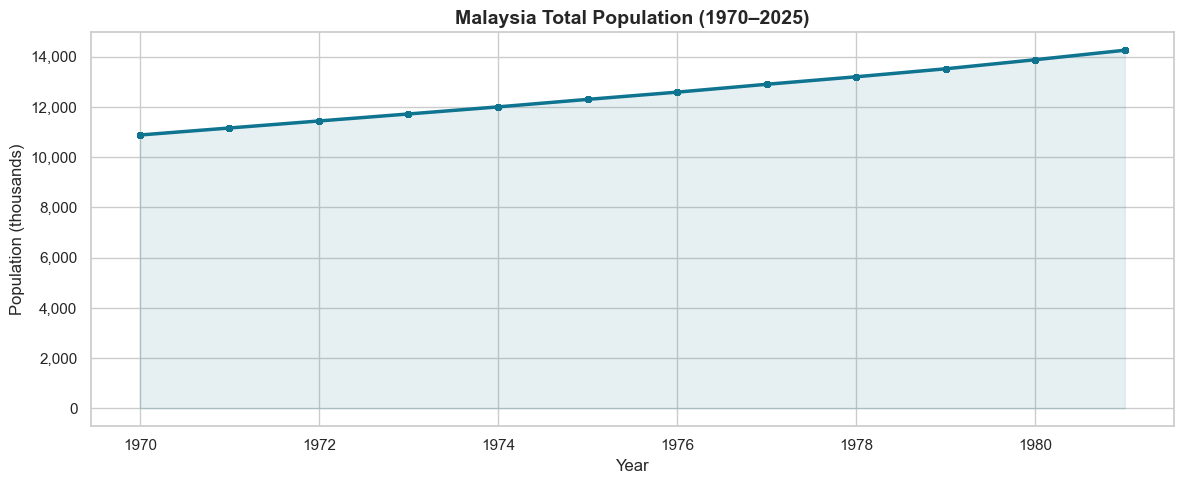

✅ Saved: outputs/01_population_growth.png


In [34]:
pop_total = pop_malaysia[
    (pop_malaysia['age'] == 'overall') &
    (pop_malaysia['sex'] == 'both') &
    (pop_malaysia['ethnicity'] == 'overall')
].copy().sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pop_total['year'], pop_total['population'],
        color='#0E7490', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(pop_total['year'], pop_total['population'],
                alpha=0.1, color='#0E7490')
ax.set_title('Malaysia Total Population (1970–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Population (thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/01_population_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/01_population_growth.png')

Year range in data: 1970 – 1981
Total rows used: 1,354,424
Age groups available: ['0-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54', '55-59', '60-64', '65-69', '70+', '70-74', '75-79', '80+']

Ageing Index by year:
  1970: young=35,681,711k | elderly=2,800,860k | index=   7.8
  1971: young=36,120,427k | elderly=2,879,623k | index=   8.0
  1972: young=36,621,711k | elderly=2,960,594k | index=   8.1
  1973: young=37,081,038k | elderly=3,040,093k | index=   8.2
  1974: young=37,544,044k | elderly=3,122,536k | index=   8.3
  1975: young=38,060,050k | elderly=3,213,076k | index=   8.4
  1976: young=38,490,669k | elderly=3,260,187k | index=   8.5
  1977: young=39,030,230k | elderly=3,319,075k | index=   8.5
  1978: young=39,492,501k | elderly=3,377,227k | index=   8.6
  1979: young=40,012,188k | elderly=3,443,476k | index=   8.6
  1980: young=40,798,342k | elderly=5,591,416k | index=  13.7
  1981: young=41,382,806k | elderly=5,773,968k | index=  14

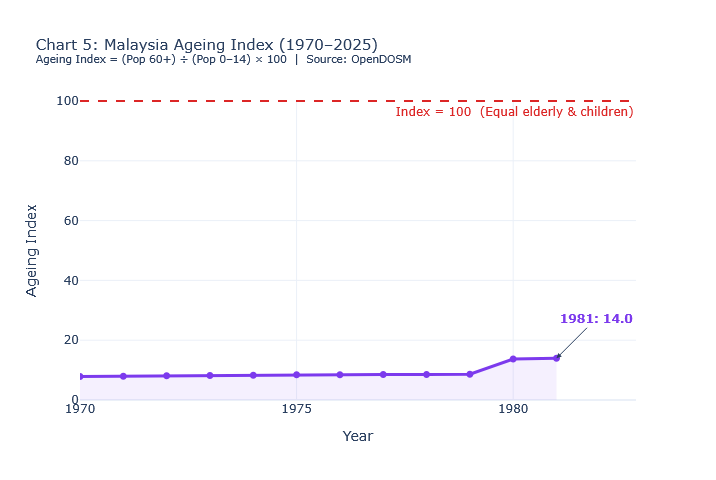


✅ Saved: outputs/chart05_ageing_index.html

📌 INSIGHT: Ageing Index (1981) = 14.0
   ⚠️  Approaching aged-nation threshold — only 86.0 points away from 100!


In [36]:
# ============================================================
# CHART: Ageing Index (Derived Metric)
# Ageing Index = (Population 60+) / (Population 0–14) × 100
# Index > 100 means more elderly than children → aged nation
# ============================================================

import plotly.graph_objects as go

pop_mx = pop_malaysia[
    (pop_malaysia['sex'] == 'both') &
    (pop_malaysia['ethnicity'] == 'overall') &
    (pop_malaysia['age'] != 'overall')
].copy()

print(f"Year range in data: {pop_mx['year'].min()} – {pop_mx['year'].max()}")
print(f"Total rows used: {len(pop_mx):,}")
print(f"Age groups available: {sorted(pop_mx['age'].unique())}")

young_ages   = ['0-4', '5-9', '10-14']
elderly_ages = ['60-64', '65-69', '70-74', '75-79', '80+']

young   = pop_mx[pop_mx['age'].isin(young_ages)].groupby('year')['population'].sum().reset_index()
elderly = pop_mx[pop_mx['age'].isin(elderly_ages)].groupby('year')['population'].sum().reset_index()

ageing = pd.merge(young, elderly, on='year', suffixes=('_young', '_elderly'))
ageing['ageing_index'] = (ageing['population_elderly'] / ageing['population_young']) * 100
ageing = ageing.sort_values('year')

print('\nAgeing Index by year:')
for _, row in ageing.iterrows():
    flag = ' ⚠️  AGED' if row['ageing_index'] >= 100 else ''
    print(f"  {int(row['year'])}: young={row['population_young']:>8,.0f}k | "
          f"elderly={row['population_elderly']:>8,.0f}k | "
          f"index={row['ageing_index']:>6.1f}{flag}")

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ageing['year'],
    y=ageing['ageing_index'],
    mode='lines+markers',
    line=dict(color='#7C3AED', width=3),
    marker=dict(size=7),
    fill='tozeroy',
    fillcolor='rgba(124,58,237,0.08)',
    name='Ageing Index',
    hovertemplate='<b>%{x}</b><br>Ageing Index = %{y:.1f}<extra></extra>'
))

fig.add_hline(
    y=100,
    line_dash='dash',
    line_color='#DC2626',
    line_width=2,
    annotation_text='Index = 100  (Equal elderly & children)',
    annotation_position='bottom right',
    annotation_font_color='#DC2626'
)

latest = ageing.iloc[-1]
fig.add_annotation(
    x=latest['year'],
    y=latest['ageing_index'],
    text=f"<b>{int(latest['year'])}: {latest['ageing_index']:.1f}</b>",
    showarrow=True,
    arrowhead=2,
    ax=40, ay=-40,
    font=dict(color='#7C3AED', size=12)
)

fig.update_layout(
    title=dict(
        text='Chart 5: Malaysia Ageing Index (1970–2025)<br>'
             '<sup>Ageing Index = (Pop 60+) ÷ (Pop 0–14) × 100  |  Source: OpenDOSM</sup>',
        font=dict(size=15)
    ),
    xaxis_title='Year',
    yaxis_title='Ageing Index',
    xaxis=dict(tickmode='linear', dtick=5),
    template='plotly_white',
    height=480,
    hovermode='x unified'
)

import os
os.makedirs('../outputs', exist_ok=True)
fig.write_html('../outputs/chart05_ageing_index.html')
fig.show()

print('\n✅ Saved: outputs/chart05_ageing_index.html')
print(f'\n📌 INSIGHT: Ageing Index ({int(latest["year"])}) = {latest["ageing_index"]:.1f}')
if latest['ageing_index'] >= 100:
    print('   🚨 Index ≥ 100 — Malaysia officially has MORE elderly than children!')
    print('   This confirms Malaysia is transitioning into an AGEING NATION.')
else:
    remaining = 100 - latest['ageing_index']
    print(f'   ⚠️  Approaching aged-nation threshold — only {remaining:.1f} points away from 100!')


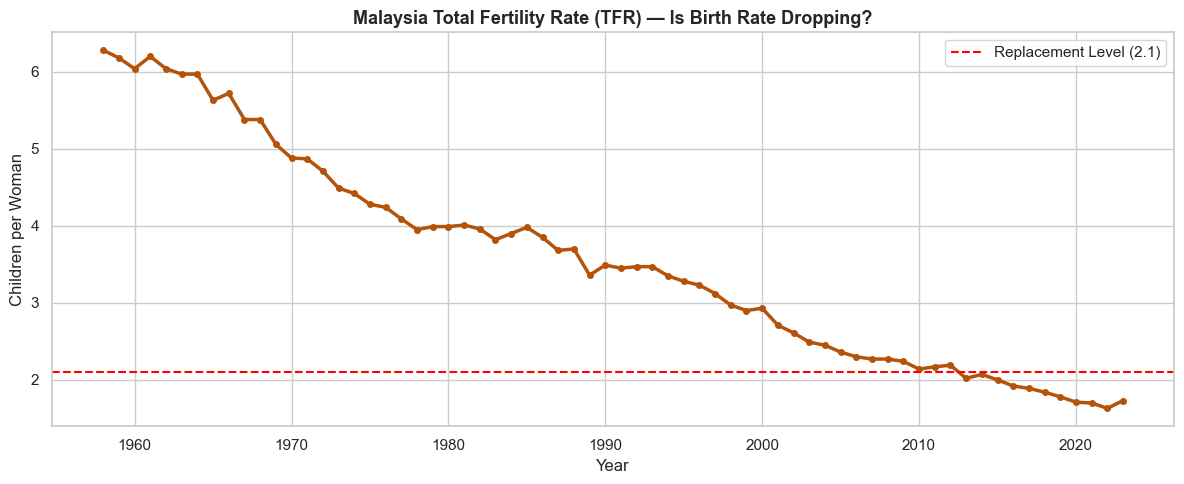

✅ Saved: outputs/02_fertility_rate.png

📌 INSIGHT: Latest TFR (2023) = 1.73
   ⚠️  BELOW replacement level of 2.1 — Malaysia is heading toward ageing population!


In [37]:
# TFR = Total Fertility Rate (age_group == 'tfr' or overall)
tfr = fertility[fertility['age_group'] == 'tfr'].copy().sort_values('year')

if len(tfr) == 0:
    # Try overall if 'tfr' label not found
    tfr = fertility.groupby('year')['fertility_rate'].mean().reset_index()
    y_col = 'fertility_rate'
else:
    y_col = 'fertility_rate'

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tfr['year'], tfr[y_col],
        color='#B45309', linewidth=2.5, marker='o', markersize=4)
ax.axhline(y=2.1, color='red', linestyle='--', linewidth=1.5,
           label='Replacement Level (2.1)')
ax.set_title('Malaysia Total Fertility Rate (TFR) — Is Birth Rate Dropping?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Children per Woman')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/02_fertility_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/02_fertility_rate.png')

latest_tfr = tfr.iloc[-1]
print(f'\n📌 INSIGHT: Latest TFR ({int(latest_tfr["year"])}) = {latest_tfr[y_col]:.2f}')
if latest_tfr[y_col] < 2.1:
    print('   ⚠️  BELOW replacement level of 2.1 — Malaysia is heading toward ageing population!')

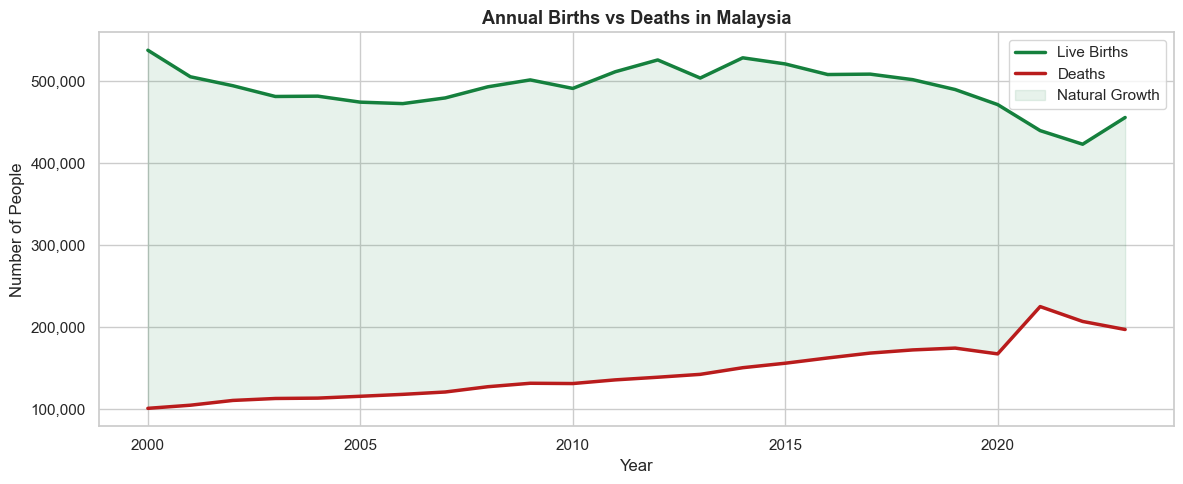

✅ Saved: outputs/03_births_vs_deaths.png


In [38]:
births_clean = births.sort_values('year')
deaths_clean = deaths.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(births_clean['year'], births_clean['abs'],
        color='#15803D', linewidth=2.5, label='Live Births')
ax.plot(deaths_clean['year'], deaths_clean['abs'],
        color='#B91C1C', linewidth=2.5, label='Deaths')
ax.fill_between(births_clean['year'],
                births_clean['abs'], deaths_clean['abs'],
                alpha=0.1, color='#15803D', label='Natural Growth')
ax.set_title('Annual Births vs Deaths in Malaysia', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of People')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/03_births_vs_deaths.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/03_births_vs_deaths.png')

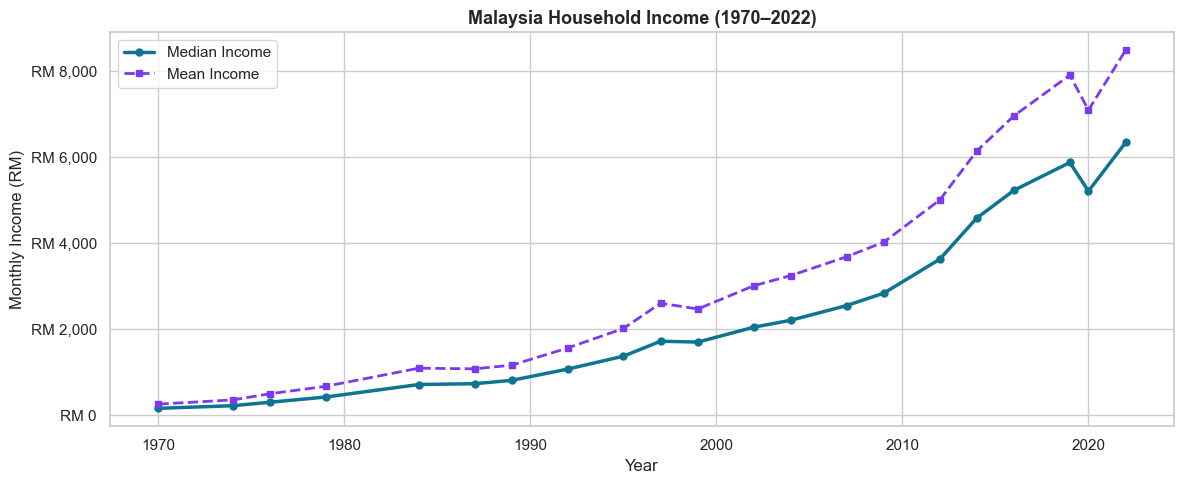

✅ Saved: outputs/04_income_growth.png

📌 INSIGHT:
   Median Income 1970: RM 166
   Median Income 2022: RM 6,338
   Growth over 52 years: +3718%


In [39]:
income_clean = hh_income.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(income_clean['year'], income_clean['income_median'],
        color='#0E7490', linewidth=2.5, label='Median Income', marker='o', markersize=5)
ax.plot(income_clean['year'], income_clean['income_mean'],
        color='#7C3AED', linewidth=2, linestyle='--', label='Mean Income', marker='s', markersize=4)
ax.set_title('Malaysia Household Income (1970–2022)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Monthly Income (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/04_income_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/04_income_growth.png')

print(f'\n📌 INSIGHT:')
print(f'   Median Income 1970: RM {income_clean[income_clean["year"]==1970]["income_median"].values[0]:,.0f}')
print(f'   Median Income 2022: RM {income_clean[income_clean["year"]==2022]["income_median"].values[0]:,.0f}')
growth = ((income_clean[income_clean['year']==2022]['income_median'].values[0] /
           income_clean[income_clean['year']==1970]['income_median'].values[0]) - 1) * 100
print(f'   Growth over 52 years: +{growth:.0f}%')

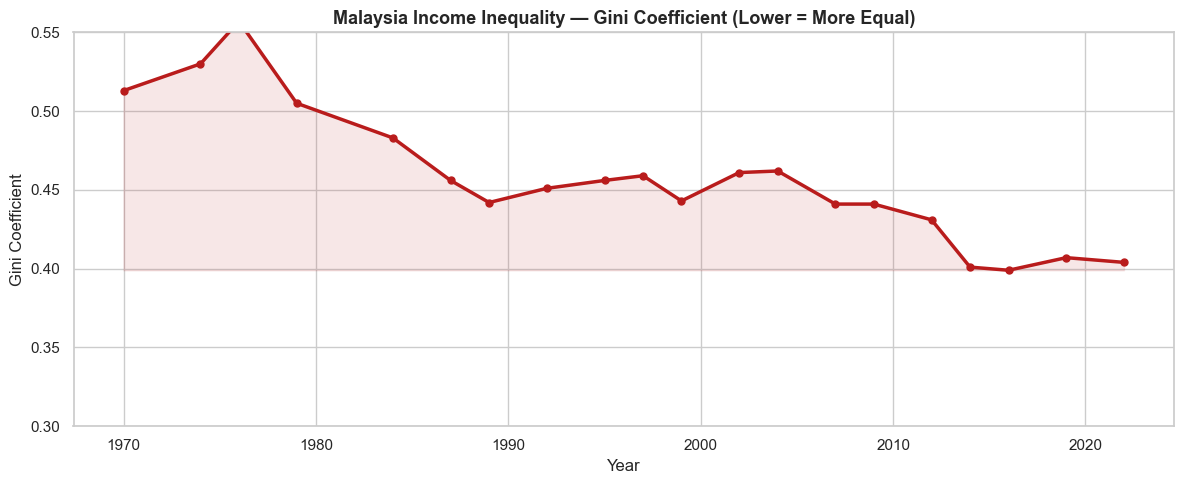

✅ Saved: outputs/05_gini_national.png

📌 INSIGHT:
   Gini 1970: 0.513
   Gini 2022: 0.404
   ✅ Inequality has DECREASED over time — but still significant


In [40]:
gini_clean = hh_inequality.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gini_clean['year'], gini_clean['gini'],
        color='#B91C1C', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(gini_clean['year'], gini_clean['gini'],
                gini_clean['gini'].min(), alpha=0.1, color='#B91C1C')
ax.set_title('Malaysia Income Inequality — Gini Coefficient (Lower = More Equal)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Gini Coefficient')
ax.set_ylim(0.3, 0.55)
plt.tight_layout()
plt.savefig('../outputs/05_gini_national.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/05_gini_national.png')

print(f'\n📌 INSIGHT:')
print(f'   Gini 1970: {gini_clean.iloc[0]["gini"]:.3f}')
print(f'   Gini 2022: {gini_clean.iloc[-1]["gini"]:.3f}')
if gini_clean.iloc[-1]['gini'] < gini_clean.iloc[0]['gini']:
    print('   ✅ Inequality has DECREASED over time — but still significant')

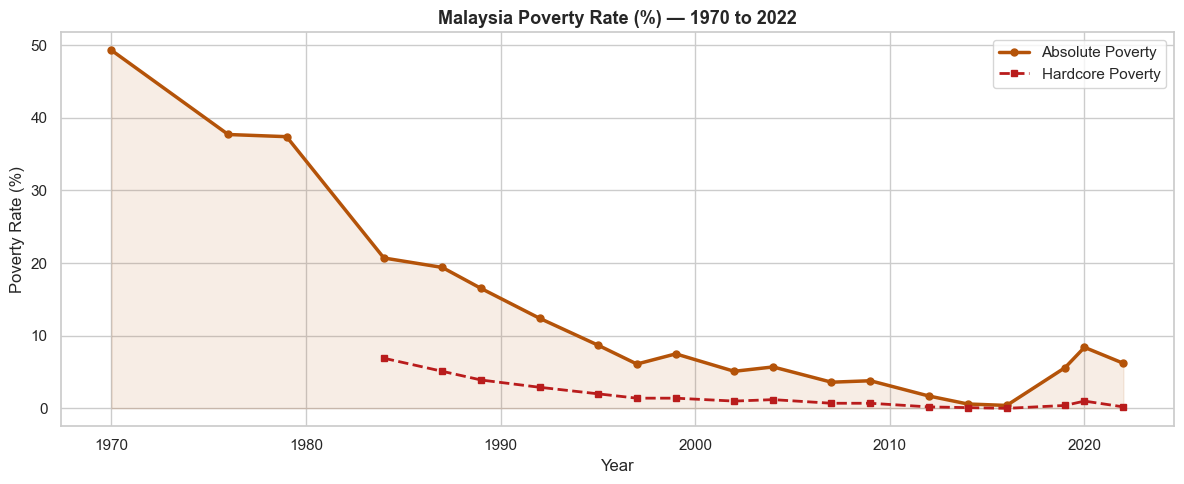

✅ Saved: outputs/06_poverty_rate.png

📌 INSIGHT:
   Poverty 1970: 49.3%
   Poverty 2022: 6.2%
   Dropped by: 43.1 percentage points — huge achievement!


In [41]:
poverty_clean = hh_poverty.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(poverty_clean['year'], poverty_clean['poverty_absolute'],
        color='#B45309', linewidth=2.5, label='Absolute Poverty', marker='o', markersize=5)
ax.plot(poverty_clean['year'], poverty_clean['poverty_hardcore'],
        color='#B91C1C', linewidth=2, linestyle='--', label='Hardcore Poverty', marker='s', markersize=4)
ax.fill_between(poverty_clean['year'], poverty_clean['poverty_absolute'],
                alpha=0.1, color='#B45309')
ax.set_title('Malaysia Poverty Rate (%) — 1970 to 2022', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Poverty Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/06_poverty_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/06_poverty_rate.png')

print(f'\n📌 INSIGHT:')
print(f'   Poverty 1970: {poverty_clean.iloc[0]["poverty_absolute"]:.1f}%')
print(f'   Poverty 2022: {poverty_clean.iloc[-1]["poverty_absolute"]:.1f}%')
drop = poverty_clean.iloc[0]['poverty_absolute'] - poverty_clean.iloc[-1]['poverty_absolute']
print(f'   Dropped by: {drop:.1f} percentage points — huge achievement!')